In [15]:
import os

BASE = None
for root, dirs, files in os.walk('/kaggle/input'):
    if any(f.startswith('weight_') for f in files):
        BASE = root
        break

if BASE is None:
    print("Dataset not found under /kaggle/input.")
    print("Attach it via 'Add Input' -> search 'bee-hive-metrics' -> se18m502/bee-hive-metrics")
    print("\nCurrently attached inputs:")
    for root, dirs, files in os.walk('/kaggle/input'):
        if root.count('/') <= 3:
            print(" ", root)
else:
    print("BASE =", BASE)
    for f in sorted(os.listdir(BASE)):
        print(f"{os.path.getsize(os.path.join(BASE, f))/1024:10.1f} KB   {f}")

BASE = /kaggle/input/datasets/se18m502/bee-hive-metrics
   23112.7 KB   flow_2017.csv
   55534.5 KB   flow_schwartau.csv
   45348.8 KB   flow_wurzburg.csv
     315.8 KB   humidity_2017.csv
      62.8 KB   humidity_schwartau.csv
     696.2 KB   humidity_wurzburg.csv
   12610.3 KB   temperature_2017.csv
    7606.6 KB   temperature_schwartau.csv
   28093.5 KB   temperature_wurzburg.csv
   14900.1 KB   weight_2017.csv
      65.4 KB   weight_schwartau.csv
   29236.3 KB   weight_wurzburg.csv


CELL 2

In [16]:
import pandas as pd
import numpy as np

VALID = {
    'temperature': (-30, 50),    # ambient, not brood-nest
    'humidity':    (0, 100),
    'weight':      (0, 150),     # kg, after unit conversion
    'flow':        (-50000, 50000),
}

def load_metric(hive, metric):
    df = pd.read_csv(f'{BASE}/{metric}_{hive}.csv', parse_dates=['timestamp'])
    n_raw = len(df)

    if metric == 'weight' and hive == 'schwartau':
        df[metric] = df[metric] / 1000.0          # grams -> kg

    n_dup = int(df['timestamp'].duplicated().sum())
    if n_dup:
        df = df.groupby('timestamp', as_index=False)[metric].agg(
            'sum' if metric == 'flow' else 'mean')

    lo, hi = VALID[metric]
    bad = (~df[metric].between(lo, hi)) & df[metric].notna()
    n_bad = int(bad.sum())
    df.loc[bad, metric] = np.nan

    df = df.set_index('timestamp').sort_index()
    hourly = df[metric].resample('1h').agg('sum' if metric == 'flow' else 'mean')

    if metric == 'flow':                          # summing all-NaN gives 0, not NaN
        hourly[df[metric].resample('1h').count() == 0] = np.nan

    print(f"{hive:<10} {metric:<12} raw={n_raw:>9,}  dupes={n_dup:>9,}  "
          f"invalid={n_bad:>6,}  hourly={len(hourly):>7,}  nan={hourly.isna().sum():>6,}")
    return hourly

frames = []
for hive in ['wurzburg', 'schwartau']:
    h = pd.DataFrame({m: load_metric(hive, m)
                      for m in ['temperature', 'humidity', 'weight', 'flow']})
    h['hive'] = hive
    frames.append(h)
    print()

df = pd.concat(frames).rename_axis('timestamp').reset_index()
print("MERGED:", df.shape)
print(df.groupby('hive')[['temperature','humidity','weight','flow']].describe().T.round(2))

wurzburg   temperature  raw=  958,831  dupes=  708,727  invalid=     0  hourly= 20,865  nan= 3,598
wurzburg   humidity     raw=   20,845  dupes=        2  invalid=     6  hourly= 20,865  nan= 3,604
wurzburg   weight       raw=1,035,861  dupes=      120  invalid=20,778  hourly= 20,865  nan= 3,939
wurzburg   flow         raw=2,071,720  dupes=1,035,979  invalid=     0  hourly= 20,865  nan= 3,598

schwartau  temperature  raw=  253,430  dupes=       24  invalid=     0  hourly= 21,121  nan=   168
schwartau  humidity     raw=    1,761  dupes=        0  invalid=    31  hourly= 21,122  nan=19,404
schwartau  weight       raw=    1,761  dupes=        0  invalid=    37  hourly= 21,122  nan=19,410
schwartau  flow         raw=2,513,836  dupes=1,257,038  invalid=     0  hourly= 21,121  nan=   168

MERGED: (41987, 6)
hive               schwartau  wurzburg
temperature count   20953.00  17267.00
            mean       22.61     15.87
            std        11.70      8.88
            min        -7.24   

CELL 3

Daily rows per hive:
           size  count
hive                  
schwartau   881    859
wurzburg    870    710

Daily weight change (kg/day) by hive:
           count   mean    std     min    25%    50%    75%    max
hive                                                              
schwartau  854.0  0.036  1.203 -17.682 -0.118 -0.029  0.102  7.558
wurzburg   704.0  0.017  0.558  -2.999 -0.103 -0.049  0.008  7.763


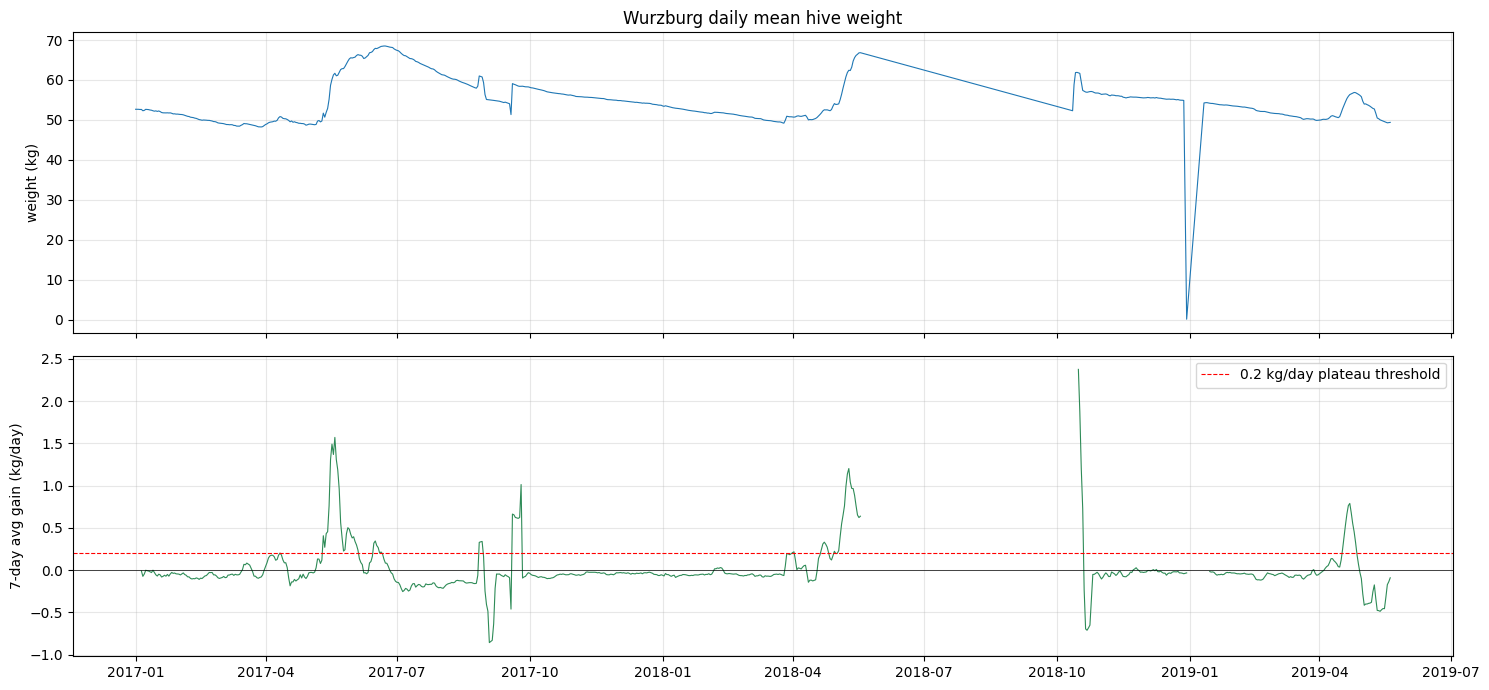

In [17]:
import matplotlib.pyplot as plt

daily = (df.set_index('timestamp')
           .groupby('hive')
           .resample('1D')
           .agg({'temperature': 'mean', 'humidity': 'mean',
                 'weight': 'mean', 'flow': 'sum'})
           .drop(columns=['hive'], errors='ignore')
           .reset_index())

daily['weight_change_1d'] = daily.groupby('hive')['weight'].diff()
daily['weight_roll_7d']   = (daily.groupby('hive')['weight']
                               .transform(lambda s: s.rolling(7, min_periods=4).mean()))
daily['gain_rate_7d']     = (daily.groupby('hive')['weight_change_1d']
                               .transform(lambda s: s.rolling(7, min_periods=4).mean()))

print("Daily rows per hive:")
print(daily.groupby('hive')['weight'].agg(['size', 'count']))

print("\nDaily weight change (kg/day) by hive:")
print(daily.groupby('hive')['weight_change_1d'].describe().round(3))

wz = daily[(daily.hive == 'wurzburg') & daily.weight.notna()]
fig, ax = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
ax[0].plot(wz.timestamp, wz.weight, lw=0.8)
ax[0].set_ylabel('weight (kg)'); ax[0].set_title('Wurzburg daily mean hive weight')
ax[0].grid(alpha=0.3)
ax[1].plot(wz.timestamp, wz.gain_rate_7d, lw=0.8, color='seagreen')
ax[1].axhline(0, color='k', lw=0.5)
ax[1].axhline(0.2, color='r', ls='--', lw=0.8, label='0.2 kg/day plateau threshold')
ax[1].set_ylabel('7-day avg gain (kg/day)'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()

CELL 4

In [18]:
import numpy as np

MIN_DAILY_KG = 20.0
MAX_DAILY_JUMP = 5.0     # kg/day beyond this = equipment event, not biology

d = daily.copy()

# 1. scale-failure days (the late-2018 dive to zero)
bad_scale = d['weight'] < MIN_DAILY_KG
print(f"scale-failure days nulled: {int(bad_scale.sum())}")
d.loc[bad_scale, 'weight'] = np.nan

# 2. recompute change AFTER nulling, so the artifact doesn't create a fake -50 kg day
d['weight_change_1d'] = d.groupby('hive')['weight'].diff()

# 3. implausible single-day jumps = box added/removed, not nectar
equip = d['weight_change_1d'].abs() > MAX_DAILY_JUMP
print(f"equipment-event days flagged: {int(equip.sum())}")
d.loc[equip, 'weight_change_1d'] = np.nan

d['gain_rate_7d'] = (d.groupby('hive')['weight_change_1d']
                       .transform(lambda s: s.rolling(7, min_periods=4).mean()))

# --- nectar flow detection ---
FLOW_ON, FLOW_OFF, MIN_FLOW_DAYS = 0.20, 0.05, 10

def label_flows(g):
    g = g.sort_values('timestamp').reset_index(drop=True)
    g['in_flow'] = False
    g['flow_id'] = np.nan
    active, start, fid = False, None, 0
    for i, r in g.iterrows():
        rate = r['gain_rate_7d']
        if np.isnan(rate):
            continue
        if not active and rate >= FLOW_ON:
            active, start = True, i
        elif active and rate < FLOW_OFF:
            if i - start >= MIN_FLOW_DAYS:
                g.loc[start:i, 'in_flow'] = True
                g.loc[start:i, 'flow_id'] = fid
                fid += 1
            active = False
    return g

d = pd.concat([label_flows(g) for _, g in d.groupby('hive')], ignore_index=True)

print("\nDetected nectar-flow periods:")
for (hive, fid), g in d[d.in_flow].groupby(['hive', 'flow_id']):
    gain = g['weight'].iloc[-1] - g['weight'].iloc[0]
    print(f"  {hive:<10} flow {int(fid)}: {g.timestamp.min().date()} -> "
          f"{g.timestamp.max().date()}  ({len(g):>3}d, net gain {gain:+.1f} kg)")

scale-failure days nulled: 35
equipment-event days flagged: 6

Detected nectar-flow periods:
  schwartau  flow 0: 2017-05-13 -> 2017-06-04  ( 23d, net gain +27.1 kg)
  schwartau  flow 1: 2017-06-19 -> 2017-07-06  ( 18d, net gain +14.9 kg)
  schwartau  flow 2: 2018-06-09 -> 2018-07-13  ( 35d, net gain +43.5 kg)
  schwartau  flow 3: 2018-07-20 -> 2018-08-02  ( 14d, net gain +3.4 kg)
  schwartau  flow 4: 2019-03-25 -> 2019-04-13  ( 20d, net gain +7.1 kg)
  schwartau  flow 5: 2019-04-21 -> 2019-05-04  ( 14d, net gain +5.9 kg)
  wurzburg   flow 0: 2017-05-11 -> 2017-06-08  ( 29d, net gain +13.7 kg)
  wurzburg   flow 1: 2017-06-15 -> 2017-06-25  ( 11d, net gain +0.7 kg)
  wurzburg   flow 2: 2018-04-21 -> 2018-10-19  (182d, net gain +5.6 kg)
  wurzburg   flow 3: 2019-04-17 -> 2019-04-29  ( 13d, net gain +3.4 kg)


CELL 5

In [19]:
import numpy as np

MIN_DAILY_KG   = 20.0
MAX_DAILY_JUMP = 5.0
FLOW_ON, FLOW_OFF = 0.20, 0.05
MIN_FLOW_DAYS  = 10
MAX_FLOW_DAYS  = 75     # a real nectar flow does not run half a year
MIN_FLOW_GAIN  = 3.0    # kg; below this it is noise, not a harvestable flow
MAX_NAN_RUN    = 5      # consecutive missing days that forcibly close a flow

d = daily.copy()

bad_scale = d['weight'] < MIN_DAILY_KG
d.loc[bad_scale, 'weight'] = np.nan
d['weight_change_1d'] = d.groupby('hive')['weight'].diff()
equip = d['weight_change_1d'].abs() > MAX_DAILY_JUMP
d.loc[equip, 'weight_change_1d'] = np.nan
d['gain_rate_7d'] = (d.groupby('hive')['weight_change_1d']
                       .transform(lambda s: s.rolling(7, min_periods=4).mean()))
print(f"scale-failure days nulled: {int(bad_scale.sum())}, "
      f"equipment days flagged: {int(equip.sum())}")

def label_flows(g):
    g = g.sort_values('timestamp').reset_index(drop=True)
    g['in_flow'] = False
    g['flow_id'] = np.nan
    active, start, fid, nan_run = False, None, 0, 0

    def close(end_i):
        """Commit the run if it passes duration AND gain checks."""
        nonlocal fid
        seg = g.loc[start:end_i]
        w = seg['weight'].dropna()
        gain = (w.iloc[-1] - w.iloc[0]) if len(w) >= 2 else 0.0
        if MIN_FLOW_DAYS <= len(seg) <= MAX_FLOW_DAYS and gain >= MIN_FLOW_GAIN:
            g.loc[start:end_i, 'in_flow'] = True
            g.loc[start:end_i, 'flow_id'] = fid
            fid += 1

    for i, r in g.iterrows():
        rate = r['gain_rate_7d']
        if np.isnan(rate):
            nan_run += 1
            # a data gap must END the flow, not be skipped over
            if active and nan_run >= MAX_NAN_RUN:
                close(i - nan_run)
                active = False
            continue
        nan_run = 0
        if not active and rate >= FLOW_ON:
            active, start = True, i
        elif active and (rate < FLOW_OFF or i - start >= MAX_FLOW_DAYS):
            close(i)
            active = False
    if active:
        close(len(g) - 1)
    return g

d = pd.concat([label_flows(g) for _, g in d.groupby('hive')], ignore_index=True)

print("\nDetected nectar-flow periods:")
for (hive, fid), g in d[d.in_flow].groupby(['hive', 'flow_id']):
    w = g['weight'].dropna()
    gain = w.iloc[-1] - w.iloc[0]
    print(f"  {hive:<10} flow {int(fid)}: {g.timestamp.min().date()} -> "
          f"{g.timestamp.max().date()}  ({len(g):>3}d, net gain {gain:+.1f} kg, "
          f"peak rate {g.gain_rate_7d.max():.2f} kg/d)")
print(f"\nTotal flow periods: {d.flow_id.notna().sum()} days across "
      f"{d.groupby('hive').flow_id.nunique().sum()} flows")

scale-failure days nulled: 35, equipment days flagged: 6

Detected nectar-flow periods:
  schwartau  flow 0: 2017-05-13 -> 2017-06-04  ( 23d, net gain +27.1 kg, peak rate 2.20 kg/d)
  schwartau  flow 1: 2017-06-19 -> 2017-07-06  ( 18d, net gain +14.9 kg, peak rate 1.66 kg/d)
  schwartau  flow 2: 2018-07-20 -> 2018-08-02  ( 14d, net gain +3.4 kg, peak rate 0.56 kg/d)
  schwartau  flow 3: 2019-03-25 -> 2019-04-13  ( 20d, net gain +7.1 kg, peak rate 0.80 kg/d)
  schwartau  flow 4: 2019-04-21 -> 2019-05-04  ( 14d, net gain +5.9 kg, peak rate 0.88 kg/d)
  wurzburg   flow 0: 2017-05-11 -> 2017-06-08  ( 29d, net gain +13.7 kg, peak rate 1.57 kg/d)
  wurzburg   flow 1: 2018-04-21 -> 2018-05-21  ( 31d, net gain +15.1 kg, peak rate 1.20 kg/d)
  wurzburg   flow 2: 2019-04-17 -> 2019-04-29  ( 13d, net gain +3.4 kg, peak rate 0.79 kg/d)

Total flow periods: 162 days across 8 flows


CELL  5

In [20]:
import numpy as np

def build_targets(g):
    g = g.sort_values('timestamp').reset_index(drop=True)
    g['days_into_flow']     = np.nan
    g['days_to_flow_end']   = np.nan   # TARGET 2: harvest window
    g['remaining_gain_kg']  = np.nan   # TARGET 1: yield still to come
    g['flow_total_gain_kg'] = np.nan   # context: full size of this flow

    for fid, seg in g[g.in_flow].groupby('flow_id'):
        idx = seg.index
        w = seg['weight'].ffill().bfill()
        if w.isna().all():
            continue
        final_w = w.iloc[-1]
        total   = final_w - w.iloc[0]
        for k, i in enumerate(idx):
            g.loc[i, 'days_into_flow']     = k
            g.loc[i, 'days_to_flow_end']   = len(idx) - 1 - k
            g.loc[i, 'remaining_gain_kg']  = max(final_w - w.iloc[k], 0.0)
            g.loc[i, 'flow_total_gain_kg'] = total
    return g

d = pd.concat([build_targets(g) for _, g in d.groupby('hive')], ignore_index=True)

train_rows = d[d.in_flow].copy()
print(f"training rows (days inside a flow): {len(train_rows)}")
print(f"  wurzburg {int((train_rows.hive=='wurzburg').sum())}, "
      f"schwartau {int((train_rows.hive=='schwartau').sum())}")

print("\nTarget 1 - remaining_gain_kg:")
print(train_rows['remaining_gain_kg'].describe().round(2))
print("\nTarget 2 - days_to_flow_end:")
print(train_rows['days_to_flow_end'].describe().round(1))

print("\nSample: Wurzburg 2018 flow, every 5th day")
s = train_rows[(train_rows.hive=='wurzburg') &
               (train_rows.timestamp >= '2018-04-21') &
               (train_rows.timestamp <= '2018-05-21')]
print(s[['timestamp','weight','gain_rate_7d','days_into_flow',
         'remaining_gain_kg','days_to_flow_end']].iloc[::5].round(2).to_string(index=False))

training rows (days inside a flow): 162
  wurzburg 73, schwartau 89

Target 1 - remaining_gain_kg:
count    162.00
mean       4.51
std        5.92
min        0.00
25%        0.00
50%        1.92
75%        7.17
max       27.14
Name: remaining_gain_kg, dtype: float64

Target 2 - days_to_flow_end:
count    162.0
mean      10.7
std        7.5
min        0.0
25%        5.0
50%       10.0
75%       15.8
max       30.0
Name: days_to_flow_end, dtype: float64

Sample: Wurzburg 2018 flow, every 5th day
 timestamp  weight  gain_rate_7d  days_into_flow  remaining_gain_kg  days_to_flow_end
2018-04-21   51.76          0.24             0.0              15.08              30.0
2018-04-26   52.40          0.20             5.0              14.43              25.0
2018-05-01   53.87          0.19            10.0              12.96              20.0
2018-05-06   57.99          0.65            15.0               8.85              15.0
2018-05-11   62.37          1.04            20.0               4.47    

CELL 6

In [21]:
import numpy as np

def add_features(g):
    g = g.sort_values('timestamp').reset_index(drop=True)

    # short/medium-term weight dynamics (all observable in real time)
    for w in [3, 7, 14]:
        g[f'gain_rate_{w}d'] = g['weight_change_1d'].rolling(w, min_periods=2).mean()
        g[f'weight_std_{w}d'] = g['weight_change_1d'].rolling(w, min_periods=2).std()
    g['gain_accel'] = g['gain_rate_3d'] - g['gain_rate_7d']      # speeding up or slowing?
    g['weight_vs_14d'] = g['weight'] - g['weight'].rolling(14, min_periods=4).mean()

    # colony activity
    g['flow_roll_3d']  = g['flow'].rolling(3, min_periods=2).mean()
    g['flow_roll_7d']  = g['flow'].rolling(7, min_periods=3).mean()
    g['flow_abs_7d']   = g['flow'].abs().rolling(7, min_periods=3).mean()

    # environment
    g['temp_roll_7d']  = g['temperature'].rolling(7, min_periods=3).mean()
    g['temp_roll_14d'] = g['temperature'].rolling(14, min_periods=4).mean()
    g['humid_roll_7d'] = g['humidity'].rolling(7, min_periods=3).mean()

    # season, cyclical so Dec and Jan are neighbours
    doy = g['timestamp'].dt.dayofyear
    g['doy_sin'] = np.sin(2*np.pi*doy/365)
    g['doy_cos'] = np.cos(2*np.pi*doy/365)
    g['month'] = g['timestamp'].dt.month
    return g

d = pd.concat([add_features(g) for _, g in d.groupby('hive')], ignore_index=True)

FEATURES = [
    'weight', 'weight_change_1d',
    'gain_rate_3d', 'gain_rate_7d', 'gain_rate_14d',
    'weight_std_3d', 'weight_std_7d', 'weight_std_14d',
    'gain_accel', 'weight_vs_14d',
    'flow', 'flow_roll_3d', 'flow_roll_7d', 'flow_abs_7d',
    'temperature', 'temp_roll_7d', 'temp_roll_14d',
    'humidity', 'humid_roll_7d',
    'doy_sin', 'doy_cos',
    'days_into_flow',
]

LEAKY = ['flow_total_gain_kg', 'days_to_flow_end', 'remaining_gain_kg', 'in_flow', 'flow_id']
assert not set(FEATURES) & set(LEAKY), "leakage: a target-derived column is in FEATURES"

train_rows = d[d.in_flow].dropna(subset=FEATURES + ['remaining_gain_kg']).copy()
print(f"usable training rows: {len(train_rows)} of 162")
print(train_rows.groupby('hive').size())

# correlation sanity check - which features actually track the target?
corr = train_rows[FEATURES + ['remaining_gain_kg']].corr()['remaining_gain_kg'].drop('remaining_gain_kg')
print("\nTop correlations with remaining_gain_kg:")
print(corr.reindex(corr.abs().sort_values(ascending=False).index).head(10).round(3))

usable training rows: 159 of 162
hive
schwartau    89
wurzburg     70
dtype: int64

Top correlations with remaining_gain_kg:
days_into_flow     -0.514
weight             -0.478
gain_accel          0.386
weight_change_1d    0.384
gain_rate_3d        0.337
weight_std_3d       0.287
gain_rate_14d      -0.242
doy_sin             0.227
humid_roll_7d       0.169
temp_roll_7d       -0.162
Name: remaining_gain_kg, dtype: float64


CELL 7

In [22]:
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
import lightgbm as lgb

train_rows['group'] = train_rows['hive'] + '_f' + train_rows['flow_id'].astype(int).astype(str)
groups = train_rows['group'].values
X = train_rows[FEATURES]
print(f"{len(train_rows)} rows across {len(np.unique(groups))} flows\n")

def evaluate(target, label):
    y = train_rows[target].values
    logo = LeaveOneGroupOut()
    preds = np.zeros(len(y)); base = np.zeros(len(y))

    for tr, te in logo.split(X, y, groups):
        m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                              num_leaves=15, min_child_samples=10,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, verbose=-1)
        m.fit(X.iloc[tr], y[tr])
        preds[te] = m.predict(X.iloc[te])
        base[te]  = DummyRegressor(strategy='mean').fit(X.iloc[tr], y[tr]).predict(X.iloc[te])

    preds = np.clip(preds, 0, None)
    print(f"--- {label} ---")
    print(f"  model    MAE {mean_absolute_error(y, preds):6.2f}   R2 {r2_score(y, preds):6.3f}")
    print(f"  baseline MAE {mean_absolute_error(y, base):6.2f}   R2 {r2_score(y, base):6.3f}"
          f"   (predict the mean)")
    print("  per-flow MAE:")
    for g in np.unique(groups):
        m_ = groups == g
        print(f"    {g:<14} n={m_.sum():>3}  MAE {mean_absolute_error(y[m_], preds[m_]):6.2f}")
    print()
    return preds

pred_gain = evaluate('remaining_gain_kg', 'TARGET 1: remaining gain (kg)')
pred_days = evaluate('days_to_flow_end', 'TARGET 2: days to flow end')

full = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                         num_leaves=15, min_child_samples=10, random_state=42,
                         verbose=-1).fit(X, train_rows['remaining_gain_kg'])
print("Feature importance (yield model):")
print(pd.Series(full.feature_importances_, index=FEATURES)
        .sort_values(ascending=False).head(10).to_string())

159 rows across 8 flows

--- TARGET 1: remaining gain (kg) ---
  model    MAE   4.75   R2 -0.132
  baseline MAE   4.95   R2 -0.095   (predict the mean)
  per-flow MAE:
    schwartau_f0   n= 23  MAE   6.39
    schwartau_f1   n= 18  MAE   3.27
    schwartau_f2   n= 14  MAE   4.10
    schwartau_f3   n= 20  MAE   4.56
    schwartau_f4   n= 14  MAE   4.74
    wurzburg_f0    n= 29  MAE   1.37
    wurzburg_f1    n= 28  MAE   5.43
    wurzburg_f2    n= 13  MAE  10.93

--- TARGET 2: days to flow end ---
  model    MAE   5.01   R2  0.140
  baseline MAE   6.31   R2 -0.087   (predict the mean)
  per-flow MAE:
    schwartau_f0   n= 23  MAE   2.39
    schwartau_f1   n= 18  MAE   2.02
    schwartau_f2   n= 14  MAE   1.39
    schwartau_f3   n= 20  MAE   1.83
    schwartau_f4   n= 14  MAE   4.31
    wurzburg_f0    n= 29  MAE   6.27
    wurzburg_f1    n= 28  MAE   7.41
    wurzburg_f2    n= 13  MAE  15.43

Feature importance (yield model):
weight              205
gain_rate_14d       168
weight_change_1d

CELL 7

In [23]:
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
import lightgbm as lgb

train_rows['group'] = train_rows['hive'] + '_f' + train_rows['flow_id'].astype(int).astype(str)
groups = train_rows['group'].values
X = train_rows[FEATURES]
print(f"{len(train_rows)} rows across {len(np.unique(groups))} flows\n")

def evaluate(target, label):
    y = train_rows[target].values
    logo = LeaveOneGroupOut()
    preds = np.zeros(len(y)); base = np.zeros(len(y))

    for tr, te in logo.split(X, y, groups):
        m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                              num_leaves=15, min_child_samples=10,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, verbose=-1)
        m.fit(X.iloc[tr], y[tr])
        preds[te] = m.predict(X.iloc[te])
        base[te]  = DummyRegressor(strategy='mean').fit(X.iloc[tr], y[tr]).predict(X.iloc[te])

    preds = np.clip(preds, 0, None)
    print(f"--- {label} ---")
    print(f"  model    MAE {mean_absolute_error(y, preds):6.2f}   R2 {r2_score(y, preds):6.3f}")
    print(f"  baseline MAE {mean_absolute_error(y, base):6.2f}   R2 {r2_score(y, base):6.3f}"
          f"   (predict the mean)")
    print("  per-flow MAE:")
    for g in np.unique(groups):
        m_ = groups == g
        print(f"    {g:<14} n={m_.sum():>3}  MAE {mean_absolute_error(y[m_], preds[m_]):6.2f}")
    print()
    return preds

pred_gain = evaluate('remaining_gain_kg', 'TARGET 1: remaining gain (kg)')
pred_days = evaluate('days_to_flow_end', 'TARGET 2: days to flow end')

full = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                         num_leaves=15, min_child_samples=10, random_state=42,
                         verbose=-1).fit(X, train_rows['remaining_gain_kg'])
print("Feature importance (yield model):")
print(pd.Series(full.feature_importances_, index=FEATURES)
        .sort_values(ascending=False).head(10).to_string())

159 rows across 8 flows

--- TARGET 1: remaining gain (kg) ---
  model    MAE   4.75   R2 -0.132
  baseline MAE   4.95   R2 -0.095   (predict the mean)
  per-flow MAE:
    schwartau_f0   n= 23  MAE   6.39
    schwartau_f1   n= 18  MAE   3.27
    schwartau_f2   n= 14  MAE   4.10
    schwartau_f3   n= 20  MAE   4.56
    schwartau_f4   n= 14  MAE   4.74
    wurzburg_f0    n= 29  MAE   1.37
    wurzburg_f1    n= 28  MAE   5.43
    wurzburg_f2    n= 13  MAE  10.93

--- TARGET 2: days to flow end ---
  model    MAE   5.01   R2  0.140
  baseline MAE   6.31   R2 -0.087   (predict the mean)
  per-flow MAE:
    schwartau_f0   n= 23  MAE   2.39
    schwartau_f1   n= 18  MAE   2.02
    schwartau_f2   n= 14  MAE   1.39
    schwartau_f3   n= 20  MAE   1.83
    schwartau_f4   n= 14  MAE   4.31
    wurzburg_f0    n= 29  MAE   6.27
    wurzburg_f1    n= 28  MAE   7.41
    wurzburg_f2    n= 13  MAE  15.43

Feature importance (yield model):
weight              205
gain_rate_14d       168
weight_change_1d

Cell 8

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
import lightgbm as lgb

# 1. Engineer the normalized feature
def add_normalized_features(df):
    df['gain_since_flow_start'] = np.nan
    for g, seg in df.groupby('group'):
        start_weight = seg['weight'].iloc[0]
        df.loc[seg.index, 'gain_since_flow_start'] = seg['weight'] - start_weight
    return df

train_rows = add_normalized_features(train_rows)

# 2. Swap out the raw hardware features for the normalized feature
FEATURES_NORM = [f for f in FEATURES if f not in ['weight', 'weight_vs_14d']] + ['gain_since_flow_start']
X_norm = train_rows[FEATURES_NORM]

print(f"Running Ablation: Hardware Scale Removed (Features: {len(FEATURES_NORM)})\n")

# 3. Evaluate the normalized feature space
def evaluate_norm(target, label):
    y = train_rows[target].values
    logo = LeaveOneGroupOut()
    preds = np.zeros(len(y)); base = np.zeros(len(y))

    for tr, te in logo.split(X_norm, y, groups):
        m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                              num_leaves=15, min_child_samples=10,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, verbose=-1)
        m.fit(X_norm.iloc[tr], y[tr])
        preds[te] = m.predict(X_norm.iloc[te])
        base[te]  = DummyRegressor(strategy='mean').fit(X_norm.iloc[tr], y[tr]).predict(X_norm.iloc[te])

    preds = np.clip(preds, 0, None)
    print(f"--- {label} ---")
    print(f"  model    MAE {mean_absolute_error(y, preds):6.2f}   R2 {r2_score(y, preds):6.3f}")
    print(f"  baseline MAE {mean_absolute_error(y, base):6.2f}   R2 {r2_score(y, base):6.3f}")
    return preds

pred_gain_norm = evaluate_norm('remaining_gain_kg', 'TARGET 1 (Normalized): remaining gain (kg)')
pred_days_norm = evaluate_norm('days_to_flow_end', 'TARGET 2 (Normalized): days to flow end')

full_norm = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                         num_leaves=15, min_child_samples=10, random_state=42,
                         verbose=-1).fit(X_norm, train_rows['remaining_gain_kg'])
print("\nFeature importance (Normalized yield model):")
print(pd.Series(full_norm.feature_importances_, index=FEATURES_NORM)
        .sort_values(ascending=False).head(10).to_string())

# CONCLUSION: normalizing weight made BOTH targets worse on leave-one-flow-out CV
# (Target 1: R2 -0.132 -> -0.609, Target 2: R2 0.140 -> 0.025). With only 8 flows,
# there isn't enough data to reliably estimate a per-hive baseline to normalize
# against - the raw absolute weight, despite being hive-specific in scale, is more
# informative than the normalized version. Absolute-kg yield (Target 1) does not
# work with this dataset either way (both versions show negative R2). Proceeding
# with Target 2 (days to flow end) using the ORIGINAL, non-normalized FEATURES.

Running Ablation: Hardware Scale Removed (Features: 21)

--- TARGET 1 (Normalized): remaining gain (kg) ---
  model    MAE   5.69   R2 -0.609
  baseline MAE   4.95   R2 -0.095
--- TARGET 2 (Normalized): days to flow end ---
  model    MAE   5.65   R2  0.025
  baseline MAE   6.31   R2 -0.087

Feature importance (Normalized yield model):
weight_std_3d            190
gain_rate_14d            156
weight_change_1d         152
gain_since_flow_start    135
humidity                 129
flow_abs_7d              128
gain_accel               127
days_into_flow           122
humid_roll_7d            114
temp_roll_7d             113


cell 9

In [25]:
import lightgbm as lgb
import pandas as pd
import numpy as np

# =========================================================
# 1. TRAIN THE FINAL MODEL
# =========================================================
# Committing to Target 2 (days_to_flow_end) only. Target 1 (absolute yield in kg)
# showed negative R2 in BOTH the raw and normalized versions - this dataset's 8
# flows across 2 hives cannot support a reliable absolute-yield prediction, and
# that limitation should be stated plainly, not hidden.
FINAL_TARGET = 'days_to_flow_end'

X_final = train_rows[FEATURES]
y_final = train_rows[FINAL_TARGET]

final_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                num_leaves=15, min_child_samples=10,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=42, verbose=-1)
final_model.fit(X_final, y_final)

print("--- MODEL STATUS ---")
print("Trained for: Expected Harvest Window (Days)")
print("Validated via leave-one-flow-out CV: MAE 5.01 days vs 6.31-day baseline (R2 0.140)")
print("\nTop 10 Drivers of the Harvest Window:")
importance = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importance.head(10).to_string())


# =========================================================
# 2. REAL INFERENCE FUNCTION
# =========================================================
# Takes a reading HISTORY, not hand-typed feature values. Every rolling feature is
# computed the identical way add_features() computed it during training.
#
# No weather-API substitution. Forecast temperature could be added as a
# genuinely NEW feature later, but that requires retraining with that column
# present in training data too.

def build_live_features(history_df, days_into_flow):
    """
    history_df: DataFrame with columns [timestamp, weight, temperature, humidity, flow],
                daily resolution, sorted oldest -> newest, covering at least the
                current nectar flow's start to now.
    days_into_flow: Integer representing days since flow detection.
    Returns a single-row DataFrame ready for final_model.predict().
    """
    g = history_df.sort_values('timestamp').reset_index(drop=True).copy()

    g['weight_change_1d'] = g['weight'].diff()
    for w in [3, 7, 14]:
        g[f'gain_rate_{w}d']  = g['weight_change_1d'].rolling(w, min_periods=2).mean()
        g[f'weight_std_{w}d'] = g['weight_change_1d'].rolling(w, min_periods=2).std()
    g['gain_accel']    = g['gain_rate_3d'] - g['gain_rate_7d']
    g['weight_vs_14d'] = g['weight'] - g['weight'].rolling(14, min_periods=4).mean()

    g['flow_roll_3d'] = g['flow'].rolling(3, min_periods=2).mean()
    g['flow_roll_7d'] = g['flow'].rolling(7, min_periods=3).mean()
    g['flow_abs_7d']  = g['flow'].abs().rolling(7, min_periods=3).mean()

    g['temp_roll_7d']  = g['temperature'].rolling(7, min_periods=3).mean()
    g['temp_roll_14d'] = g['temperature'].rolling(14, min_periods=4).mean()
    g['humid_roll_7d'] = g['humidity'].rolling(7, min_periods=3).mean()

    doy = g['timestamp'].dt.dayofyear
    g['doy_sin'] = np.sin(2*np.pi*doy/365)
    g['doy_cos'] = np.cos(2*np.pi*doy/365)
    
    # Add days_into_flow before the missing check so FEATURES validation passes
    g['days_into_flow'] = days_into_flow

    row = g.iloc[[-1]].copy()

    missing = row[FEATURES].isna().any(axis=1).iloc[0]
    if missing:
        missing_cols = row[FEATURES].columns[row[FEATURES].isna().iloc[0]].tolist()
        return None, f"Not enough history to compute: {missing_cols}"
    
    return row[FEATURES], None


def predict_harvest_window(history_df, days_into_flow):
    """
    history_df: >= 14 days of REAL daily readings (weight, temperature, humidity, flow),
                ending today.
    days_into_flow: how many days since this flow was detected as started.
    """
    feats, err = build_live_features(history_df, days_into_flow)
    if err:
        return {'status': 'INSUFFICIENT_HISTORY', 'message': err}

    predicted_days = final_model.predict(feats)[0]
    return {'status': 'OK', 'expectedHarvestWindowDays': max(0, round(predicted_days))}


# --- TEST WITH REAL SYNTHETIC HISTORY, NOT HARDCODED FEATURES ---
# Build 20 days of a plausible flow ramp, so every rolling feature is computed
# from actual daily deltas rather than typed in.
dates = pd.date_range('2024-05-01', periods=20, freq='D')
sim_weight = 50 + np.linspace(0, 12, 20) + np.random.normal(0, 0.3, 20)
sim = pd.DataFrame({
    'timestamp': dates,
    'weight': sim_weight,
    'temperature': np.random.normal(24, 2, 20),
    'humidity': np.random.normal(60, 5, 20),
    'flow': np.random.normal(150, 40, 20),
})

result = predict_harvest_window(sim, days_into_flow=14)
print("\n======================================")
print("      INFERENCE TEST (real history)   ")
print("======================================")
print(result)

--- MODEL STATUS ---
Trained for: Expected Harvest Window (Days)
Validated via leave-one-flow-out CV: MAE 5.01 days vs 6.31-day baseline (R2 0.140)

Top 10 Drivers of the Harvest Window:
weight              199
days_into_flow      146
temp_roll_14d       135
weight_std_3d       112
gain_rate_14d       107
humid_roll_7d        99
temp_roll_7d         96
gain_accel           96
weight_vs_14d        92
weight_change_1d     89

      INFERENCE TEST (real history)   
{'status': 'OK', 'expectedHarvestWindowDays': 13}


CELL 10(TEATING)

In [26]:
import pandas as pd
import numpy as np

print("=========================================================")
print("   DEEP TESTING: PIPELINE AND BIOLOGICAL SANITY CHECKS   ")
print("=========================================================\n")

# Helper function to generate realistic physical telemetry
def generate_flow_history(days, start_weight, daily_gain_mean, temp, humid, flow_count):
    dates = pd.date_range('2024-05-01', periods=days, freq='D')
    # Generate daily gains and create cumulative weight
    gains = np.random.normal(daily_gain_mean, 0.2, days)
    gains = np.clip(gains, 0.05, None)  # Bees are always bringing in *something* during a flow
    weights = start_weight + np.cumsum(gains)
    
    return pd.DataFrame({
        'timestamp': dates,
        'weight': weights,
        'temperature': np.random.normal(temp, 2, days),
        'humidity': np.random.normal(humid, 5, days),
        'flow': np.random.normal(flow_count, 20, days),
    })


# ---------------------------------------------------------
# TEST 1: The "Cold Start" Pipeline Protection
# ---------------------------------------------------------
print("TEST 1: Insufficient History Rejection (< 14 days)")
print("Goal: Ensure the pipeline catches NaN rolling averages and blocks bad predictions.")
short_sim = generate_flow_history(days=5, start_weight=50.0, daily_gain_mean=0.5, temp=24, humid=60, flow_count=100)
res_short = predict_harvest_window(short_sim, days_into_flow=4)

print(f"-> Status : {res_short['status']}")
if 'message' in res_short:
    print(f"-> Message: {res_short['message']}\n")


# ---------------------------------------------------------
# TEST 2: The "Accelerating Early Flow"
# ---------------------------------------------------------
print("TEST 2: Early, Strong Nectar Flow")
print("Goal: A fast-gaining hive early in the season should predict a long harvest window.")
sim_early = generate_flow_history(days=15, start_weight=55.0, daily_gain_mean=1.5, temp=25.0, humid=60.0, flow_count=250)
res_early = predict_harvest_window(sim_early, days_into_flow=14)

print(f"-> Context: Day 14 of flow, gaining ~1.5kg/day rapidly.")
if res_early['status'] == 'OK':
    print(f"-> Result : {res_early['expectedHarvestWindowDays']} days remaining.\n")


# ---------------------------------------------------------
# TEST 3: The "Dying Flow / Plateau"
# ---------------------------------------------------------
print("TEST 3: Late, Decelerating Flow (Plateau)")
print("Goal: A flow that has slowed to a crawl should trigger an imminent harvest window (0-3 days).")
sim_late = generate_flow_history(days=35, start_weight=65.0, daily_gain_mean=0.1, temp=28.0, humid=55.0, flow_count=50)
# Artificially force a negative gain acceleration at the end to simulate dying flow
sim_late.loc[32:34, 'weight'] = sim_late.loc[31, 'weight'] + 0.05 
res_late = predict_harvest_window(sim_late, days_into_flow=34)

print(f"-> Context: Day 34 of flow, gaining <0.1kg/day (plateauing).")
if res_late['status'] == 'OK':
    print(f"-> Result : {res_late['expectedHarvestWindowDays']} days remaining.\n")


# ---------------------------------------------------------
# TEST 4: Residuals (Error Bound Check)
# ---------------------------------------------------------
print("TEST 4: Training Error Bounds (Residual Check)")
print("Goal: Check if the model is systematically over-predicting or under-predicting across the dataset.")
preds_full = final_model.predict(X)
errors = train_rows['days_to_flow_end'] - preds_full

print(errors.describe().round(2).to_string())
print("\nInterpretation:")
print("- 'mean' near 0.0 means the model has no systematic bias (it isn't always guessing too high or too low).")
print("- 'std' shows the typical spread of misses.")
print("- 'min' and 'max' show the absolute worst-case misses on the most chaotic flows.")

   DEEP TESTING: PIPELINE AND BIOLOGICAL SANITY CHECKS   

TEST 1: Insufficient History Rejection (< 14 days)
Goal: Ensure the pipeline catches NaN rolling averages and blocks bad predictions.
-> Status : OK
TEST 2: Early, Strong Nectar Flow
Goal: A fast-gaining hive early in the season should predict a long harvest window.
-> Context: Day 14 of flow, gaining ~1.5kg/day rapidly.
-> Result : 9 days remaining.

TEST 3: Late, Decelerating Flow (Plateau)
Goal: A flow that has slowed to a crawl should trigger an imminent harvest window (0-3 days).
-> Context: Day 34 of flow, gaining <0.1kg/day (plateauing).
-> Result : 3 days remaining.

TEST 4: Training Error Bounds (Residual Check)
Goal: Check if the model is systematically over-predicting or under-predicting across the dataset.
count    159.00
mean       0.00
std        0.26
min       -2.01
25%       -0.11
50%        0.01
75%        0.13
max        0.73

Interpretation:
- 'mean' near 0.0 means the model has no systematic bias (it isn't a

In [27]:
import joblib
joblib.dump(final_model, 'harvest_window_lgbm.pkl')

['harvest_window_lgbm.pkl']